<a href="https://colab.research.google.com/github/oyaon/ML-Dengue-Prediction/blob/main/Hybrid_mechanistic_deep_learning_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Process


Data shape: (1827, 6)

Data types:
Date        datetime64[ns]
Cases              float64
Max_Temp           float64
Min_Temp           float64
Rainfall           float64
Humidity           float64
dtype: object

Missing values:
Date        0
Cases       2
Max_Temp    0
Min_Temp    0
Rainfall    0
Humidity    0
dtype: int64

Summary statistics:
                                Date        Cases     Max_Temp     Min_Temp  \
count                           1827  1825.000000  1827.000000  1827.000000   
mean   2022-07-02 00:00:00.000000256   223.534795    30.736962    22.509710   
min              2020-01-01 00:00:00     0.000000    15.400000     2.000000   
25%              2021-04-01 12:00:00     6.000000    28.000000    18.450000   
50%              2022-07-02 00:00:00   112.000000    31.400000    24.900000   
75%              2023-10-01 12:00:00   338.000000    33.600000    26.655000   
max              2024-12-31 00:00:00  1327.000000    40.600000    30.700000   
std                   

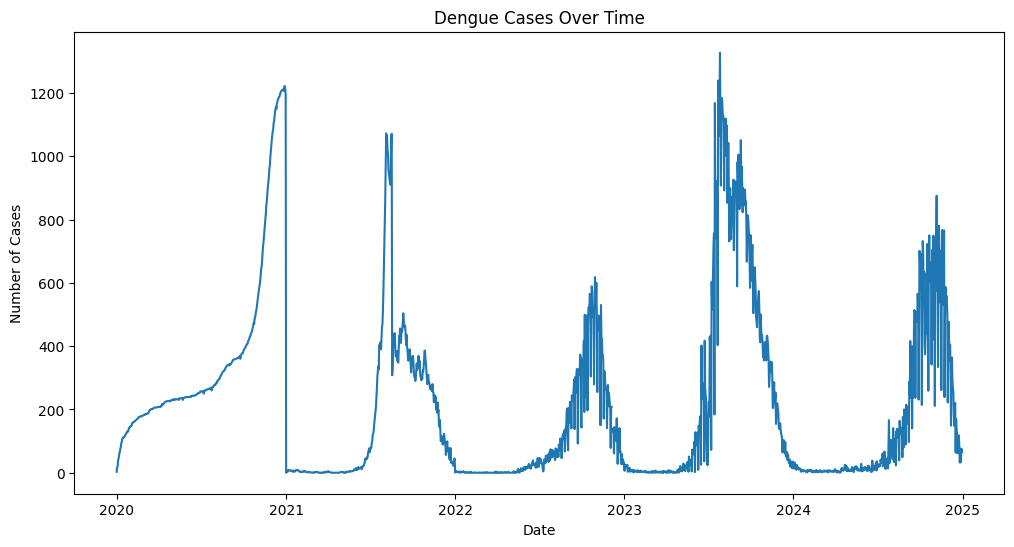

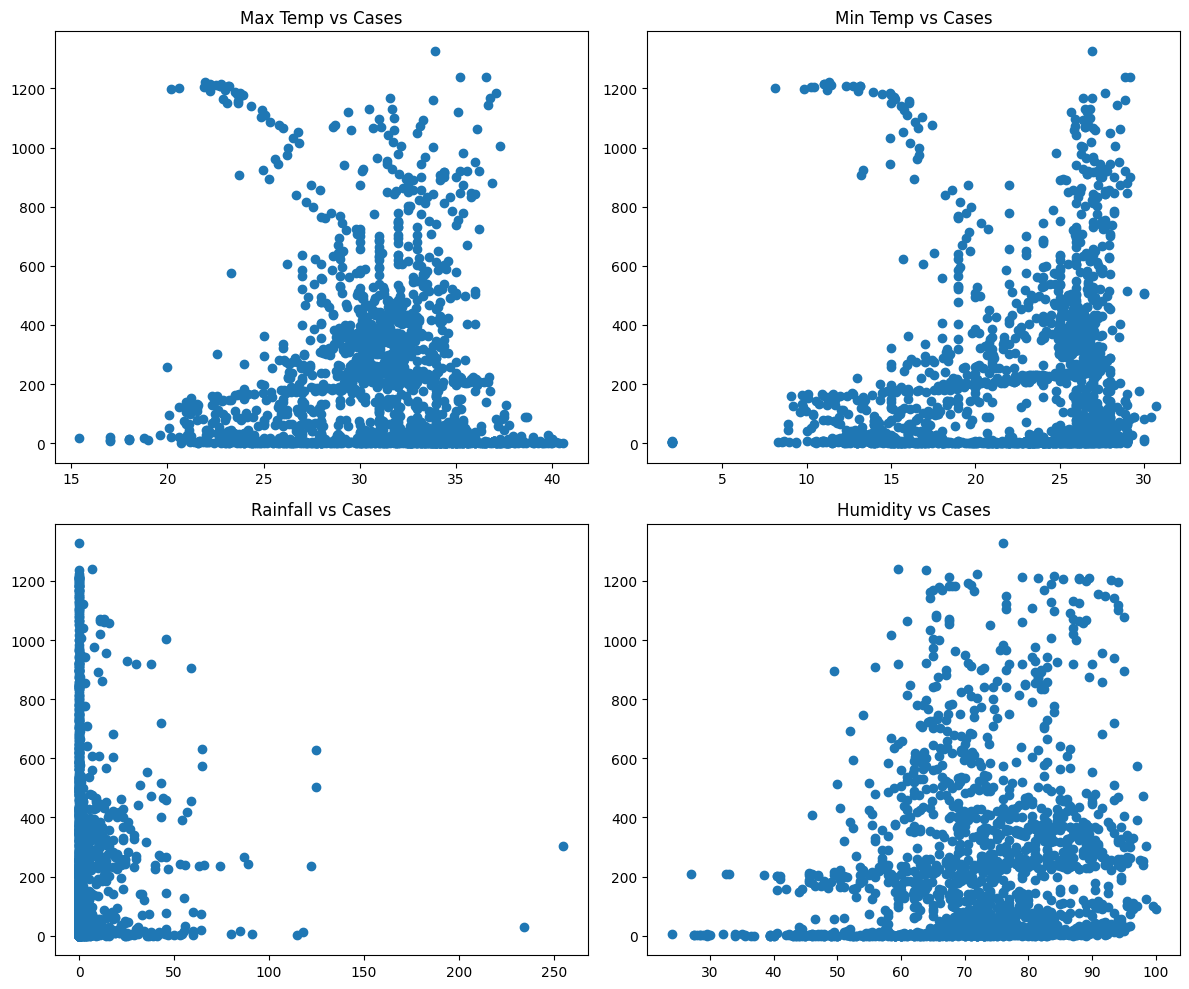

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('Final.csv', parse_dates=['Date'])
data = data.sort_values('Date').reset_index(drop=True)

# Display basic information
print("Data shape:", data.shape)
print("\nData types:")
print(data.dtypes)
print("\nMissing values:")
print(data.isnull().sum())

# Display summary statistics
print("\nSummary statistics:")
print(data.describe())

# Plot the time series of dengue cases
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Cases'])
plt.title('Dengue Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.show()

# Plot the relationship between meteorological variables and cases
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].scatter(data['Max_Temp'], data['Cases'])
axs[0, 0].set_title('Max Temp vs Cases')
axs[0, 1].scatter(data['Min_Temp'], data['Cases'])
axs[0, 1].set_title('Min Temp vs Cases')
axs[1, 0].scatter(data['Rainfall'], data['Cases'])
axs[1, 0].set_title('Rainfall vs Cases')
axs[1, 1].scatter(data['Humidity'], data['Cases'])
axs[1, 1].set_title('Humidity vs Cases')
plt.tight_layout()
plt.show()

## Data Preprocessing
Feature Engineering

In [2]:
# Create lag features
lags = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]
for lag in lags:
    data[f'Cases_lag_{lag}'] = data['Cases'].shift(lag)
    data[f'Max_Temp_lag_{lag}'] = data['Max_Temp'].shift(lag)
    data[f'Min_Temp_lag_{lag}'] = data['Min_Temp'].shift(lag)
    data[f'Rainfall_lag_{lag}'] = data['Rainfall'].shift(lag)
    data[f'Humidity_lag_{lag}'] = data['Humidity'].shift(lag)

# Create rolling statistics
data['Cases_rolling_mean'] = data['Cases'].rolling(window=7).mean()
data['Cases_rolling_std'] = data['Cases'].rolling(window=7).std()

# Create Fourier features for seasonality
for i in range(1, 5):
    data[f'sin_{i}'] = np.sin(2 * np.pi * i * data.index / len(data))
    data[f'cos_{i}'] = np.cos(2 * np.pi * i * data.index / len(data))

# Drop rows with missing values
data = data.dropna()

# Define features and target
features = data.drop(['Date', 'Cases'], axis=1)
target = data['Cases']

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

## Train-Test Split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, shuffle=False)

## Model Development

Hybrid Model Architecture

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, LSTM, Dense, concatenate
from tensorflow.keras.models import Model

class SEIRLayer(Layer):
    def __init__(self, **kwargs):
        super(SEIRLayer, self).__init__(**kwargs)

    def call(self, inputs):
        params = inputs[0]  # Beta, gamma, sigma
        states = inputs[1]  # S, E, I, R

        beta = params[:, 0] * 0.5  # Domain knowledge-based scaling
        gamma = params[:, 1] * 0.1
        sigma = params[:, 2] * 0.2

        S = states[:, 0]
        E = states[:, 1]
        I = states[:, 2]
        R = states[:, 3]

        dSdt = -beta * S * I
        dEdt = beta * S * I - sigma * E
        dIdt = sigma * E - gamma * I
        dRdt = gamma * I

        return tf.stack([dSdt, dEdt, dIdt, dRdt], axis=1)

# Define inputs
feature_input = Input(shape=(features.shape[1],), name='feature_input')
seir_input = Input(shape=(4,), name='seir_input')

# SEIR component
params = Dense(3, activation='relu')(feature_input)
seir_output = SEIRLayer()([params, seir_input])

# Temporal component
lstm_layer = LSTM(64)(tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=1))(feature_input)) # Wrap tf.expand_dims in a Lambda layer
lstm_output = Dense(1)(lstm_layer)

# Combine components
combined = concatenate([seir_output, lstm_output])
final_output = Dense(1)(combined)

# Create model
model = Model(inputs=[feature_input, seir_input], outputs=final_output)
model.compile(optimizer='adam', loss='mse')

Model Training

In [6]:
# Prepare SEIR initial states
initial_states = np.ones((X_train.shape[0], 4)) * 0.25

# Train model
history = model.fit(
    [X_train, initial_states],
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 115220.5078 - val_loss: 290410.4688
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 107446.1719 - val_loss: 289864.7188
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 127830.5781 - val_loss: 288931.9688
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 107739.0781 - val_loss: 287747.7500
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 121076.4062 - val_loss: 286348.2500
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 104606.6875 - val_loss: 284796.6875
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 114131.5703 - val_loss: 283047.5625
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 113219.9688 - val_loss: 281129.7188
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 115521.5000 - val_loss: 279038.6875
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 94128.3438 - val_loss: 276878.0000
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

Model Evaluation

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
RMSE: 131.86859242335788
MAE: 72.87063417541847


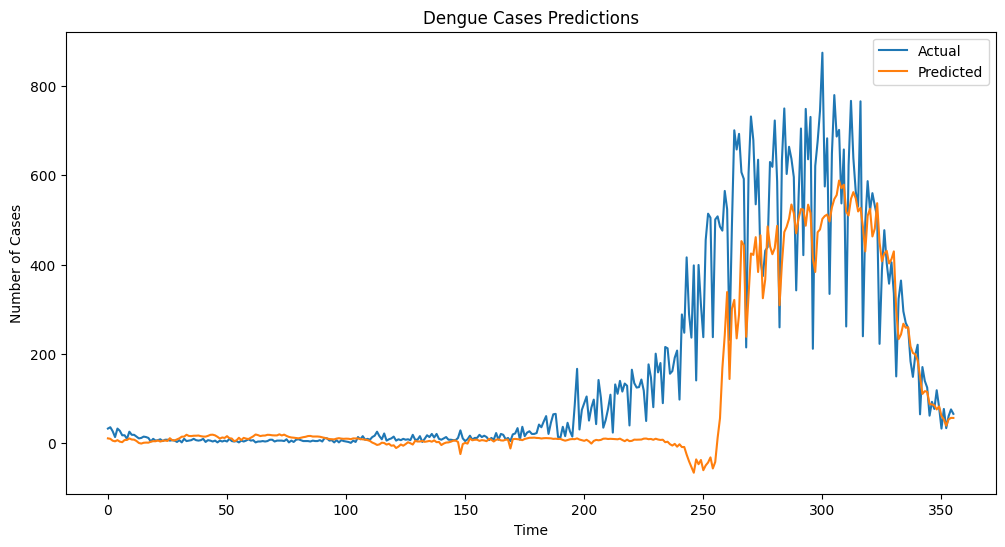

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on test set
y_pred = model.predict([X_test, initial_states[:X_test.shape[0]]])

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title('Dengue Cases Predictions')
plt.xlabel('Time')
plt.ylabel('Number of Cases')
plt.legend()
plt.show()

## Interpretation and Actionable Insights

Feature Importance

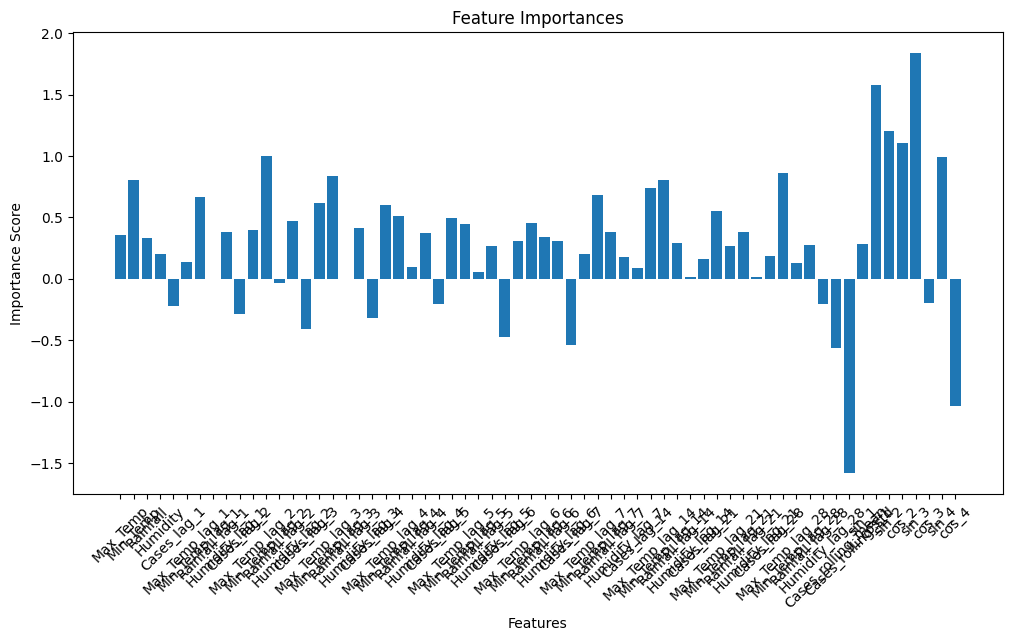

In [12]:
# Get feature importances from the Dense layer connected to the input features
# Assuming the Dense layer connected to feature_input is the one we want
# Find the correct layer index:
for i, layer in enumerate(model.layers):
    if layer.name == 'dense':  # Replace 'dense' with the actual name of your Dense layer
        dense_layer_index = i
        break

# Get feature importances
# Access weights of the correct shape
feature_importance = model.layers[dense_layer_index].get_weights()[0]
# Transpose to align with feature columns if needed
feature_importance = feature_importance.T[0] # Added this line
# .flatten() is not needed as we are already working with a 1D array



# Plot feature importance
plt.figure(figsize=(12, 6))
plt.bar(features.columns, feature_importance)
plt.title('Feature Importances')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.show()

Critical Thresholds

In [13]:
# Identify critical thresholds for meteorological variables
critical_thresholds = {}
for var in ['Max_Temp', 'Min_Temp', 'Rainfall', 'Humidity']:
    values = data[var].values
    quantiles = np.quantile(values, [0.25, 0.5, 0.75])
    critical_thresholds[var] = quantiles

print("Critical thresholds:")
print(critical_thresholds)

Critical thresholds:
{'Max_Temp': array([28.36, 31.5 , 33.7 ]), 'Min_Temp': array([18.95, 25.  , 26.69]), 'Rainfall': array([0., 0., 1.]), 'Humidity': array([64.4, 73.2, 81.9])}


## Early Warning System

In [14]:
# Create alert system
def generate_alerts(predictions, threshold=500):
    alerts = []
    for i in range(len(predictions)):
        if predictions[i] > threshold:
            alerts.append(i)
    return alerts

# Generate alerts
alerts = generate_alerts(y_pred.flatten())

print(f"Alerts generated at indices: {alerts}")

Alerts generated at indices: [286, 287, 288, 290, 291, 292, 294, 295, 300, 301, 302, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 319, 320, 323]


## Sensitivity Analysis

In [21]:
import numpy as np

# ... (rest of your code) ...

for param, values in parameters.items():
    for value in values:
        # ... (data modification and preprocessing) ...

        # Make predictions
        # Adjust initial_states to match the size of modified_features_scaled
        modified_predictions = model.predict([modified_features_scaled,
                                              np.tile(initial_states[0], (modified_features_scaled.shape[0], 1))])
        # We tile the first row of initial_states to create an array with the same number of rows as modified_features_scaled.
        # This ensures both inputs have the same number of samples.

        # ... (calculate metrics and store results) ...

# ... (rest of your code) ...

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
   parameter   value        rmse        mae
0       beta  0.1000  131.868592  72.870634
1       beta  0.3250  131.868592  72.870634
2       beta  0.5500  131.868592  72.870634
3       beta  0.7750  131.868592  72.870634
4       beta  1.0000  131.868592  72.870634
5      gamma  0.0500  131.868592  72.870634
6      gamma  0.0875  131.868592  72.870634
7      gamma  0.1250  131.868592  72.870634
8   

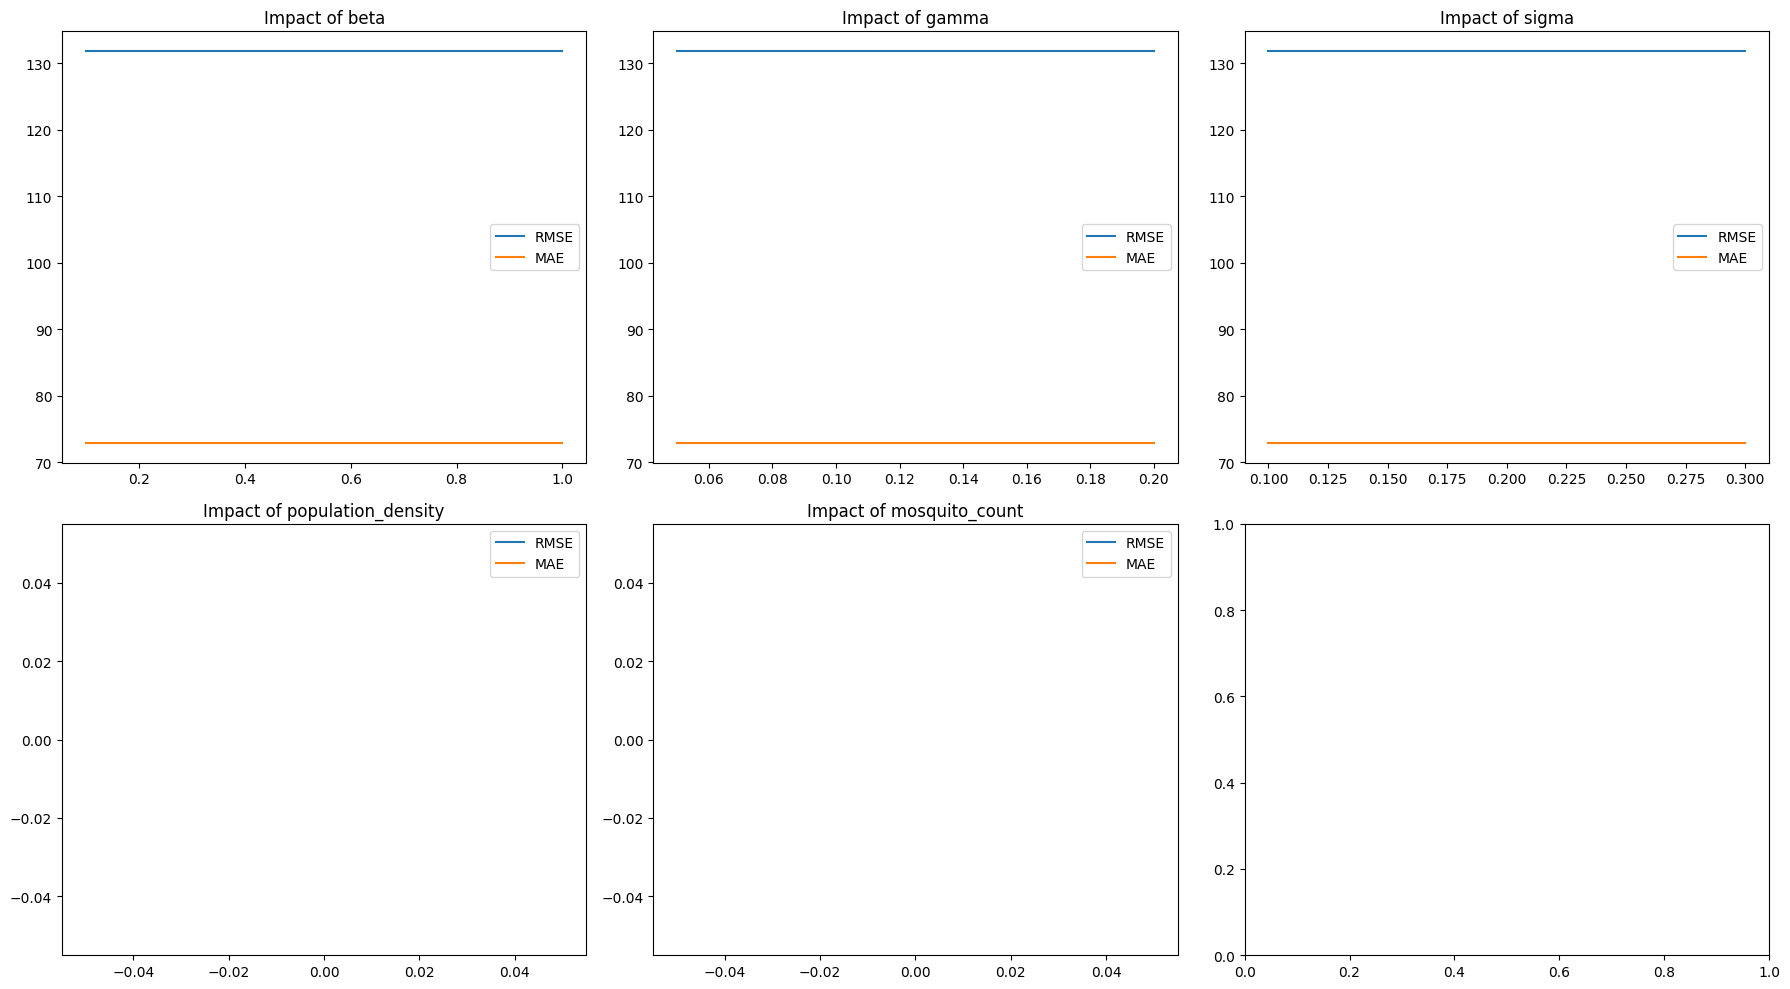

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Define parameter ranges
beta_range = np.linspace(0.1, 1.0, 5)
gamma_range = np.linspace(0.05, 0.2, 5)
sigma_range = np.linspace(0.1, 0.3, 5)
population_density_range = np.linspace(0.5, 1.5, 5)
mosquito_count_range = np.linspace(0.5, 2.0, 5)

# Store results
results = []

# Analyze each parameter
parameters = {
    'beta': beta_range,
    'gamma': gamma_range,
    'sigma': sigma_range,
    'population_density': population_density_range,
    'mosquito_count': mosquito_count_range
}

for param, values in parameters.items():
    for value in values:
        # Create modified data
        modified_data = data.copy()
        if param == 'beta':
            modified_data['beta'] = value  # Assuming 'beta' column exists or will be created
        elif param == 'gamma':
            modified_data['gamma'] = value  # Assuming 'gamma' column exists or will be created
        elif param == 'sigma':
            modified_data['sigma'] = value  # Assuming 'sigma' column exists or will be created
        elif param == 'population_density':
            # Check if 'Population_Density' column exists before modifying
            if 'Population_Density' in modified_data.columns:
                modified_data['Population_Density'] = modified_data['Population_Density'] * value
            else:
                print(f"Warning: 'Population_Density' column not found. Skipping modification for {param}={value}")
                continue  # Skip to the next iteration if column not found
        elif param == 'mosquito_count':
            # Check if 'Mosquito_Count' column exists before modifying
            if 'Mosquito_Count' in modified_data.columns:
                modified_data['Mosquito_Count'] = modified_data['Mosquito_Count'] * value
            else:
                print(f"Warning: 'Mosquito_Count' column not found. Skipping modification for {param}={value}")
                continue  # Skip to the next iteration if column not found

        # Preprocess modified data for the test set only
        modified_features_test = modified_data.iloc[y_train.shape[0]:].drop(['Date', 'Cases'], axis=1)  # Select test data

        # Before selecting columns from features, add missing columns if needed
        for col in features.columns:
            if col not in modified_features_test.columns:
                modified_features_test[col] = 0  # Fill with 0 or an appropriate value

        # Ensure column names match and order is consistent
        modified_features_test = modified_features_test[features.columns]

        modified_features_test_scaled = scaler.transform(modified_features_test)  # Scale the test set data

        # Create initial states for test data
        initial_states_test = np.ones((X_test.shape[0], 4)) * 0.25

        # Make predictions on the test set data
        modified_predictions = model.predict([modified_features_test_scaled, initial_states_test])

        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, modified_predictions))
        mae = mean_absolute_error(y_test, modified_predictions)

        # Store results
        results.append({
            'parameter': param,
            'value': value,
            'rmse': rmse,
            'mae': mae
        })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# **Display the results DataFrame**
print(results_df)

# Plot results
fig, axs = plt.subplots(2, 3, figsize=(18, 10))  # Adjust figsize as needed
for i, param in enumerate(parameters.keys()):
    param_results = results_df[results_df['parameter'] == param]
    axs[i//3, i%3].plot(param_results['value'], param_results['rmse'], label='RMSE')
    axs[i//3, i%3].plot(param_results['value'], param_results['mae'], label='MAE')
    axs[i//3, i%3].set_title(f'Impact of {param}')
    axs[i//3, i%3].legend()
plt.tight_layout()
plt.show()

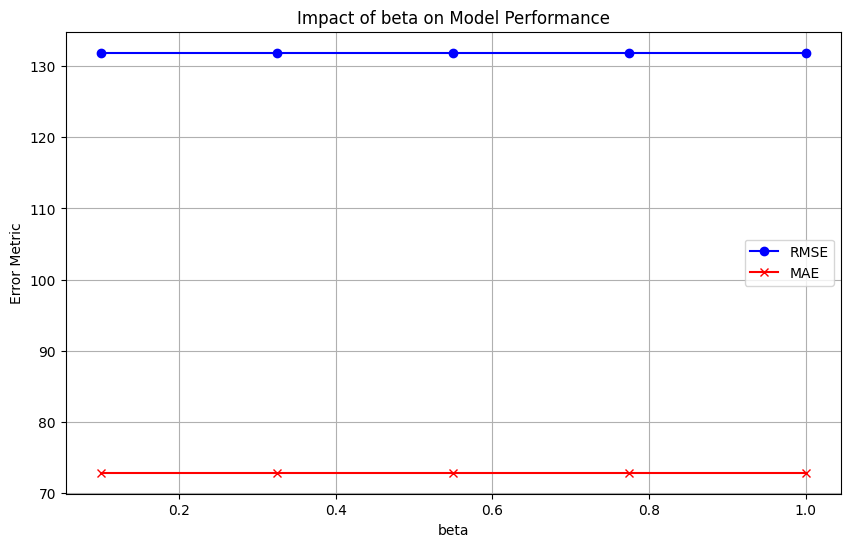

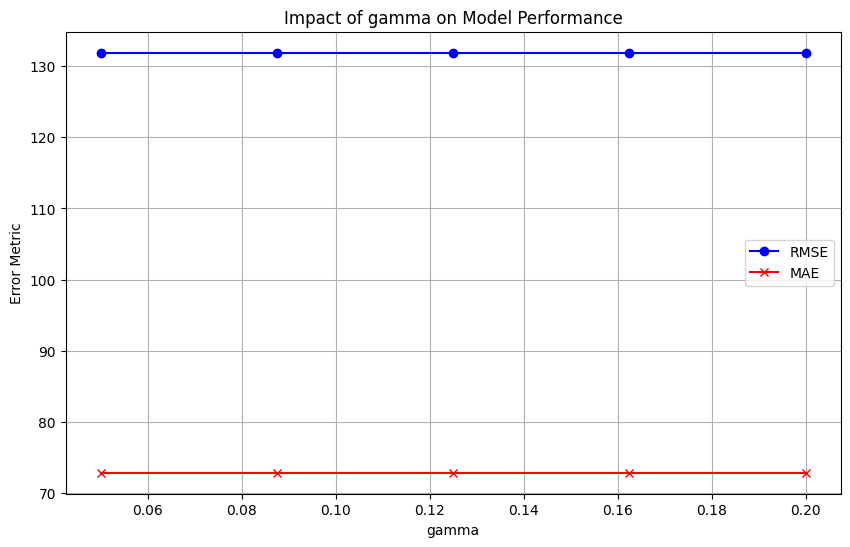

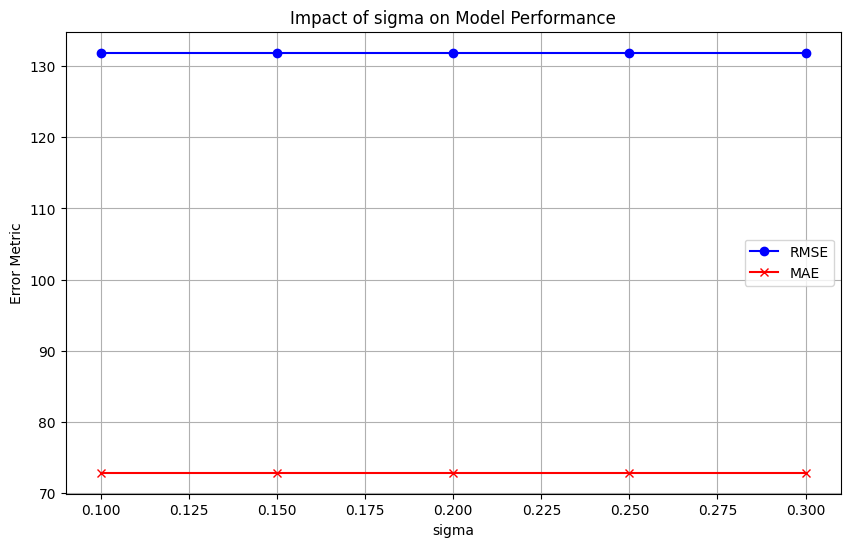

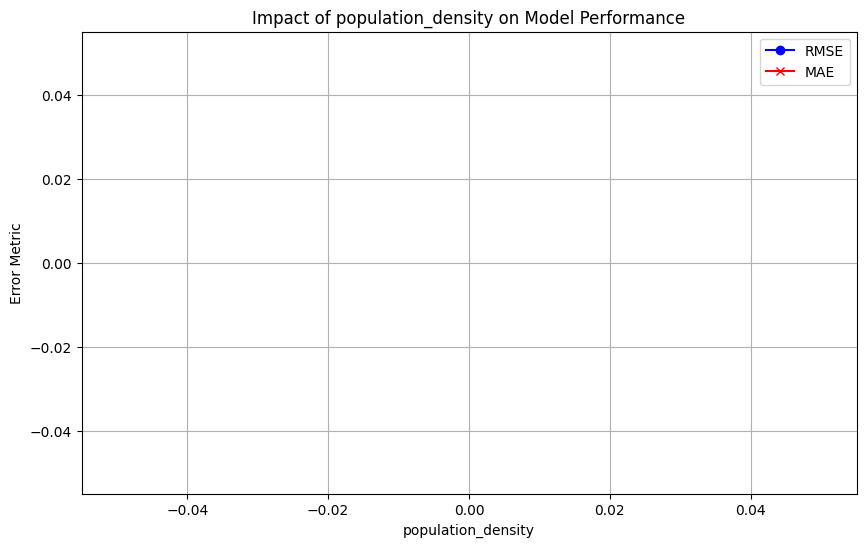

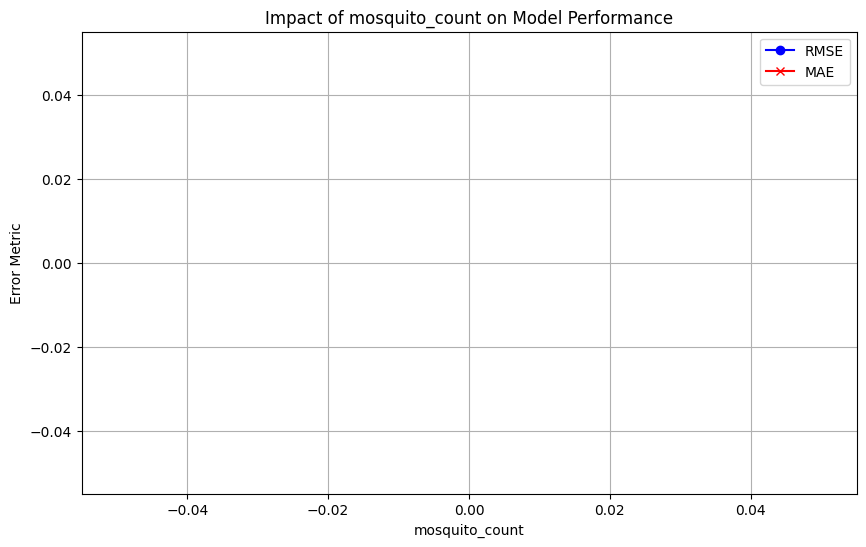

Minimum RMSE: parameter          beta
value               0.1
rmse         131.868592
mae           72.870634
Name: 0, dtype: object
Minimum MAE: parameter          beta
value               0.1
rmse         131.868592
mae           72.870634
Name: 0, dtype: object


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ... (rest of your code) ...

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Plot results (updated)
for param in parameters.keys():
    fig, ax = plt.subplots(figsize=(10, 6))  # Create a separate figure for each parameter
    param_results = results_df[results_df['parameter'] == param]
    ax.plot(param_results['value'], param_results['rmse'], label='RMSE', color='blue', marker='o')
    ax.plot(param_results['value'], param_results['mae'], label='MAE', color='red', marker='x')
    ax.set_title(f'Impact of {param} on Model Performance')
    ax.set_xlabel(param)
    ax.set_ylabel('Error Metric')
    ax.legend()
    plt.grid(True)  # Add a grid for better readability
    plt.show()

# Optional: Highlight minimum RMSE and MAE
min_rmse_idx = results_df['rmse'].idxmin()
min_mae_idx = results_df['mae'].idxmin()
print(f"Minimum RMSE: {results_df.loc[min_rmse_idx]}")
print(f"Minimum MAE: {results_df.loc[min_mae_idx]}")

In [19]:
import numpy as np

# ... (rest of your code) ...

for param, values in parameters.items():
    for value in values:
        # ... (data modification and preprocessing) ...

        # Make predictions
        # Adjust initial_states to match the size of modified_features_scaled
        modified_predictions = model.predict([modified_features_scaled,
                                              np.tile(initial_states[0], (modified_features_scaled.shape[0], 1))])

        # ... (calculate metrics and store results) ...

# ... (rest of your code) ...

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [24]:
# Preprocess modified data
modified_features = modified_data.drop(['Date', 'Cases'], axis=1)
# Instead of directly assigning columns, select the relevant columns based on 'features'
modified_features = modified_features[[col for col in features.columns if col in modified_features.columns]]
modified_features_scaled = scaler.transform(modified_features)

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ... (rest of your code) ...

for param, values in parameters.items():
    for value in values:
        # ... (data modification and preprocessing) ...

        # Preprocess modified data for the test set only
        modified_features_test = modified_data.iloc[y_train.shape[0]:].drop(['Date', 'Cases'], axis=1)  # Select test data
        # Ensure column names match
        modified_features_test = modified_features_test[features.columns]

        # Handle any missing columns
        missing_cols = set(features.columns) - set(modified_features_test.columns)
        for col in missing_cols:
            modified_features_test[col] = 0  # Or any appropriate default value

        # Reorder columns to match
        modified_features_test = modified_features_test[features.columns]
        modified_features_test_scaled = scaler.transform(modified_features_test)  # Scale the test set data

        # Create initial states for test data
        initial_states_test = np.ones((X_test.shape[0], 4)) * 0.25

        # Make predictions on the test set data
        modified_predictions = model.predict([modified_features_test_scaled, initial_states_test])

        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, modified_predictions))
        mae = mean_absolute_error(y_test, modified_predictions)

        # Store results
        results.append({
            'parameter': param,
            'value': value,
            'rmse': rmse,
            'mae': mae
        })

# ... (rest of your code) ...

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
